In [104]:
import av
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from PIL import Image
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
av.logging.set_level(av.logging.VERBOSE)

In [6]:
base_path = '/Users/tom/Development/carbot_ai_model/data/rollouts/'
data_folder = '1762202252.156224'

base_time_path = f'{base_path}/{data_folder}/start_time.txt'
with open(base_time_path, 'r') as f:
    line = f.read().strip()
    base_time = int(line)

start_time_path = f'{base_path}/{data_folder}/timestamp_log.txt'
with open(start_time_path, 'r') as f:
    line = f.read().strip()
    start_time = int(line)

actual_start_time = start_time + base_time


In [7]:
output_folder = '/Users/tom/Development/carbot_ai_model/frames'

In [170]:

av.logging.set_level(av.logging.VERBOSE)
path = f'{base_path}/{data_folder}/recording.mp4'
container = av.open(path)
for index, frame in enumerate(container.decode(video=0)):
    t_sec = float(frame.pts * frame.time_base)
    t_ns = int(t_sec * 1e9)
    monotonic_time = t_ns + actual_start_time

    

    #img = frame.to_ndarray(format='rgb24')
    #Image.fromarray(img).save(f"{output_folder}/frame_{monotonic_time}.png")

In [103]:
def get_closest_frame_timestamp_index(target_timestamp, frame_timestamps):
    idx = np.searchsorted(frame_timestamps, target_timestamp)
    if idx == 0:
        return 0
    if idx == len(frame_timestamps):
        return len(frame_timestamps) - 1
    before = frame_timestamps[idx - 1]
    after = frame_timestamps[idx]
    if abs(after - target_timestamp) < abs(before - target_timestamp):
        return idx
    else:
        return idx - 1


def process_trajectory(data_folder, output_folder, num_trajectory):

    ## first grab the start time of the first frame in monotonic time from the linux clock.
    base_time_path = f'{data_folder}/start_time.txt'
    with open(base_time_path, 'r') as f:
        line = f.read().strip()
        base_time = int(line)

    start_time_path = f'{data_folder}/timestamp_log.txt'
    with open(start_time_path, 'r') as f:
        line = f.read().strip()
        start_time = int(line)

    actual_start_time = start_time + base_time


    ## create output folder for this trajectory
    output_folder = f'{output_folder}/trajectory_{num_trajectory}'
    os.makedirs(output_folder, exist_ok=True)

    ## first, load in trajectory data and remove all instances where robot is not moving.
    df = pd.read_csv(f'{data_folder}/rollout_data.csv')
    non_zero_index = df[df['speed'] >= 0.05].index
    start_index = max(0, non_zero_index[0] -1)
    end_index = min(len(df)-1, non_zero_index[-1] + 1)
    trimmed = df.iloc[start_index:end_index+1]
    print(f'Start index: {start_index}, End index: {end_index}, Original length: {len(df)}, Trimmed length: {len(trimmed)}')

    ## next, load in video frames and match timestamps to trajectory data
    timestamps = np.sort(trimmed['timestamp'].values)
    first_timestamp = timestamps[0]
    last_timestamp = timestamps[-1]

    path = f'{data_folder}/recording.mp4'
    container = av.open(path)
    frame_index = 0
    pose_indices = []
    # decodes at 30 fps.
    for index, frame in enumerate(container.decode(video=0)):
        t_sec = float(frame.pts * frame.time_base)
        t_ns = int(t_sec * 1e9)
        monotonic_time = t_ns + actual_start_time

        ## with 9, we taking a frame every 300 ms since video is 30 fps.
        if (index % 9 != 0) or ((monotonic_time < first_timestamp)):
            continue

        if (monotonic_time > last_timestamp):
            break

        pose_index = get_closest_frame_timestamp_index(monotonic_time, timestamps)
        pose_indices.append(pose_index)

        img = frame.to_ndarray(format='rgb24')
        Image.fromarray(img).save(f"{output_folder}/frame_{frame_index}.png")
        frame_index += 1

    output_dataframe = pd.DataFrame(columns=['x', 'y', 'yaw', 'speed'])
    output_dataframe = pd.concat([output_dataframe, trimmed.iloc[pose_indices, 1:]]).reset_index(drop=True)
    output_dataframe.to_csv(f'{output_folder}/trajectory_data.csv', index=False)

In [105]:
base_path = '/Users/tom/Development/carbot_ai_model'

for index, trajectory in enumerate(os.listdir(f'{base_path}/data/rollouts')):
    data_folder = f'{base_path}/data/rollouts/{trajectory}'
    output_folder = f'{base_path}/processed_trajectories'
    process_trajectory(data_folder, output_folder, num_trajectory=index)


No accelerated colorspace conversion found from yuv420p to rgb24.


Start index: 224, End index: 679, Original length: 938, Trimmed length: 456


/var/folders/94/b4rb28zd70zg_3hd1pz8r6rh0000gn/T/ipykernel_48958/2838178926.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_dataframe = pd.concat([output_dataframe, trimmed.iloc[pose_indices, 1:]]).reset_index(drop=True)
No accelerated colorspace conversion found from yuv420p to rgb24.
 (repeated 29 more times)


Start index: 784, End index: 1253, Original length: 1455, Trimmed length: 470


No accelerated colorspace conversion found from yuv420p to rgb24.
/var/folders/94/b4rb28zd70zg_3hd1pz8r6rh0000gn/T/ipykernel_48958/2838178926.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_dataframe = pd.concat([output_dataframe, trimmed.iloc[pose_indices, 1:]]).reset_index(drop=True)
No accelerated colorspace conversion found from yuv420p to rgb24.
 (repeated 31 more times)
No accelerated colorspace conversion found from yuv420p to rgb24.


...

/var/folders/94/b4rb28zd70zg_3hd1pz8r6rh0000gn/T/ipykernel_48958/2838178926.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_dataframe = pd.concat([output_dataframe, trimmed.iloc[pose_indices, 1:]]).reset_index(drop=True)
No accelerated colorspace conversion found from yuv420p to rgb24.
 (repeated 33 more times)
No accelerated colorspace conversion found from yuv420p to rgb24.


Start index: 91, End index: 530, Original length: 765, Trimmed length: 440


/var/folders/94/b4rb28zd70zg_3hd1pz8r6rh0000gn/T/ipykernel_48958/2838178926.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_dataframe = pd.concat([output_dataframe, trimmed.iloc[pose_indices, 1:]]).reset_index(drop=True)
No accelerated colorspace conversion found from yuv420p to rgb24.
 (repeated 28 more times)


Start index: 358, End index: 758, Original length: 951, Trimmed length: 401


No accelerated colorspace conversion found from yuv420p to rgb24.
/var/folders/94/b4rb28zd70zg_3hd1pz8r6rh0000gn/T/ipykernel_48958/2838178926.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_dataframe = pd.concat([output_dataframe, trimmed.iloc[pose_indices, 1:]]).reset_index(drop=True)


The dateset will use w=8, follow 8 waypoints. i.e must predict the next 800ms worth of positional data. 

In [106]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')


def normalise_heading(yaw):
    while yaw > np.pi:
        yaw -= 2 * np.pi
    while yaw < -np.pi:
        yaw += 2 * np.pi
    return yaw

class TrajectorySample:
    def __init__(self, data_folder, transform=None, num_waypoints=8, data_type=torch.float32):
        self.data_folder = data_folder
        self.transform = transform
        self.trajectory_data = pd.read_csv(f'{data_folder}/trajectory_data.csv')
        self.trajectory_data.drop(columns='speed', inplace=True)
        self.num_waypoints = num_waypoints
        self.data_type = data_type

    def orient_to_reference(self, current_waypoint, waypoints):
        ref_x = current_waypoint['x']
        ref_y = current_waypoint['y']
        ref_yaw = current_waypoint['yaw']

        h_sin = np.sin(-ref_yaw)
        h_cos = np.cos(-ref_yaw)

        ref_yaw = normalise_heading(ref_yaw)

        for i in range(len(waypoints)):
            dx = waypoints.at[i, 'x'] - ref_x
            dy = waypoints.at[i, 'y'] - ref_y

            # Rotate by -ref_yaw
            rotated_x = dx * h_cos - dy * h_sin
            rotated_y = dx * h_sin + dy * h_cos

            waypoints.at[i, 'x'] = rotated_x
            waypoints.at[i, 'y'] = rotated_y

            # orient yaw to heading =0. 
            waypoints.at[i, 'yaw'] -= ref_yaw
            waypoints.at[i, 'yaw'] = normalise_heading(waypoints.at[i, 'yaw'])

    def __getitem__(self, idx):
        if (idx < 0) or (idx >= len(self.trajectory_data)):
            raise IndexError("Index out of bounds")
    
        o_t = Image.open(f'{self.data_folder}/frame_{idx}.png').convert('RGB')
        if self.transform:
            o_t = self.transform(o_t).type(self.data_type).to(device)

        waypoints = None

        current_waypoint = self.trajectory_data.iloc[idx]

        if (idx == self.__len__() - 1):
            waypoints = self.trajectory_data.iloc[[idx]]
        else:
            end_index = min(idx + self.num_waypoints + 1, len(self.trajectory_data))
            waypoints = self.trajectory_data.iloc[idx + 1:end_index]

        current_len = len(waypoints)
        if current_len < self.num_waypoints:
            last_row = waypoints.iloc[-1].copy()
            repeated = pd.concat([last_row.to_frame().T] * (self.num_waypoints - current_len), ignore_index=True)
            waypoints = pd.concat([waypoints, repeated], ignore_index=True)

        waypoints = waypoints.reset_index(drop=True)
        self.orient_to_reference(current_waypoint, waypoints)


        waypoints = waypoints[['x', 'y']]
        return o_t, torch.tensor(waypoints.values, dtype=self.data_type).to(device)

    def __len__(self):
        return len(self.trajectory_data)

class WaypointDataset(Dataset):
    def __init__(self, data_folder, w_num=8, transform=None, data_type=torch.float32):
        self.data_folder = data_folder
        self.w_num = w_num
        self.transform = transform
        self.trajectories = []
        self.len = 0
        self.data_type = data_type
        self.load_trajectories()

    def load_trajectories(self):
        for trajectory in os.listdir(self.data_folder):
            trajectory_path = f'{self.data_folder}/{trajectory}'
            sample = TrajectorySample(trajectory_path, num_waypoints=self.w_num, transform=self.transform, data_type=self.data_type)
            self.trajectories.append(sample)
            self.len += len(sample)

    def map_index_to_trajectory(self, idx):
        cumulative_length = 0
        for traj_index, trajectory in enumerate(self.trajectories):
            traj_length = len(trajectory)
            if idx < cumulative_length + traj_length:
                sample_index = idx - cumulative_length
                return traj_index, sample_index
            cumulative_length += traj_length
        raise IndexError("Index out of bounds")
    
    def __getitem__(self, idx):
        traj_index, sample_index = self.map_index_to_trajectory(idx)
        return self.trajectories[traj_index][sample_index]
    
    def __len__(self):
        return self.len
    
    def denormalize_image(self, tensor):
        for t, m, s in zip(tensor, mean, std):
            t.mul_(s).add_(m)
        return tensor
    
    def view_sample(self, idx):
        o_t, waypoints = self.__getitem__(idx)
        o_t = o_t.to('cpu')
        o_t = self.denormalize_image(o_t)
        o_t = o_t.permute(1, 2, 0).numpy()
        plt.imshow(o_t)
        plt.show()

        plot_waypoints(waypoints)

def plot_waypoints(waypoints):
    xy = waypoints[:, :2]
    x = xy[:, 0].cpu().numpy()
    y = xy[:, 1].cpu().numpy()

    # Axis scale
    max_value = max(max(abs(x)), max(abs(y))) + 0.5

    plt.figure(figsize=(6, 6))
    plt.plot(x, y, marker='o')

    # Label points 1–8
    for i in range(8):
        plt.text(x[i], y[i], str(i + 1), fontsize=12, ha='right', va='bottom')

    # Formatting
    plt.xlim(-max_value, max_value)
    plt.ylim(-max_value, max_value)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.title('Waypoints in Robot-Centric Frame')
    plt.grid()
    plt.show()



Using device: mps


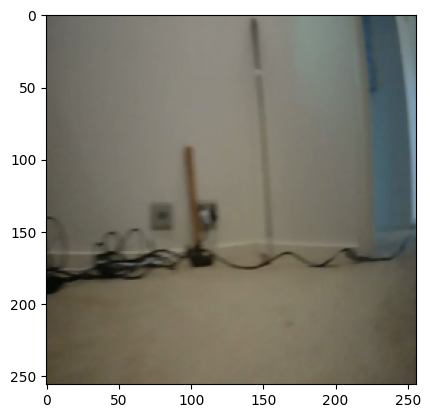

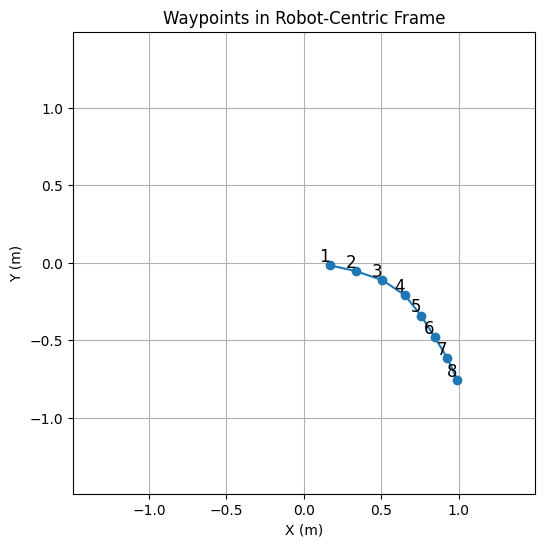

318


In [116]:
import torchvision.transforms as transforms

mean = [0.485, 0.456, 0.406]
std = [0.225, 0.225, 0.225]

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

dataset = WaypointDataset(data_folder=f'{base_path}/processed_trajectories', w_num=8, transform=transform)
dataset.view_sample(np.random.randint(0, len(dataset)))
print(len(dataset))

## Model

In [33]:
class Convnet2DBlock(nn.Module):
    """"
    Block use Conv2D -> GroupNorm -> MISH
    """
    def __init__(self, in_chans: int, out_chans: int, kernel_size: int, n_groups=8):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels=in_chans, out_channels=out_chans, kernel_size=kernel_size, padding=kernel_size//2),
            nn.GroupNorm(num_groups=n_groups, num_channels=out_chans),
            nn.Mish())

    def forward(self, x):
        return self.block(x)
    
class ResetNetBlock(nn.Module):
    def __init__(self, in_chans: int, out_chans: int, kernel_size: int, n_groups=8):
        super().__init__() 
        self.conv = Convnet2DBlock(in_chans=in_chans, out_chans=out_chans, kernel_size=kernel_size)
        self.resnet = nn.Conv2d(in_channels=in_chans, out_channels=out_chans, kernel_size=kernel_size, padding=kernel_size//2) if in_chans != out_chans else nn.Identity()

    def forward(self, x):
        out = self.conv(x)
        res = self.resnet(x)
        return out + res
    
class Encoder(nn.Module):
    def __init__(self, in_chans = 3, levels = [64, 128, 256], kernel_size=3, n_groups=8):
        super().__init__()
        self.levels = levels
        self.blocks = nn.ModuleList()

        zipped_levels = zip([in_chans] + levels[:-1], levels)

        for (in_ch, out_ch) in zipped_levels:
            self.blocks.append(nn.Sequential(ResetNetBlock(in_ch, out_ch, kernel_size, n_groups),
                                             nn.MaxPool2d(kernel_size=2, stride=2)))

    def forward(self, x):
        for block in self.blocks:
            x = block(x) 
        return x
    
class ModelV1(nn.Module):
    def __init__(self, in_chans=3, W=256, H=256, waypoint_num=8, encoder_levels=[64, 128, 256], kernel_size=3, n_groups=8):
        super().__init__()
        self.encoder = Encoder(in_chans=in_chans, levels=encoder_levels, kernel_size=kernel_size, n_groups=n_groups)
        C, H, W = 3, 256, 256
        with torch.no_grad():
            dummy = torch.zeros((1, C, H, W))
            encoded = self.encoder(dummy)
            flat_dim = encoded.view(1, -1).shape[1]

        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(flat_dim, 512),
            nn.Mish(),
            nn.Linear(512, 256), 
            nn.Mish(), 
            nn.Linear(256, waypoint_num * 2))

    def forward(self, x):
        x = self.encoder(x)
        x = self.flatten(x)
        x = self.fc(x)
        x = x.view(x.size(0), -1, 2)  # Reshape to (batch_size, waypoint_num, 2)
        return x

In [117]:
## setup params
C, H, W = 3, 256, 256
waypoint_num = 8
batch_size = 32
train_split = 0.90
data_type = torch.float32

# data params. 
base_path = '/Users/tom/Development/carbot_ai_model'
data_folder = 'processed_trajectories'

mean = [0.485, 0.456, 0.406]
std = [0.225, 0.225, 0.225]


transform = transforms.Compose([
    transforms.Resize((H, W)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

full_dataset = WaypointDataset(data_folder=f'{base_path}/{data_folder}', w_num=waypoint_num, transform=transform, data_type=data_type)
train_idx, val_idx = train_test_split(list(range(len(full_dataset))), train_size=train_split, random_state=42) 

  # Create data loaders
train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
val_sampler = torch.utils.data.SubsetRandomSampler(val_idx)

train_loader = DataLoader(full_dataset, batch_size=batch_size, 
                            sampler=train_sampler, num_workers=0)
val_loader = DataLoader(full_dataset, batch_size=batch_size, 
                        sampler=val_sampler, num_workers=0)

In [118]:

model = ModelV1().to(device).type(data_type)
dummy_input = torch.ones((batch_size, C, H, W)).to(device).to(data_type)
output = model(dummy_input)
print(output.shape)  # Should be (batch_size, 8, 2)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

torch.Size([32, 8, 2])
Total parameters: 135,096,208


In [119]:
## Setup optimizer and loss function
train_iters = 20
learning_rate = 1e-3
warmup_steps = 1500

def warmup_lr(step):
    return min(step, warmup_steps) / warmup_steps

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, warmup_lr)
criterion = nn.MSELoss()

In [120]:
avg_losses = []
avg_val_losses = []

min_val_loss = float('inf')

for epoch in range(train_iters):
    model.train()
    running_loss = 0.0
    for i, (inputs, targets) in enumerate(train_loader):
        inputs = inputs.to(device).to(data_type)
        targets = targets.to(device).to(data_type)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{train_iters}], Loss: {avg_loss:.4f}')

    # Validation step
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device).to(data_type)
            targets = targets.to(device).to(data_type)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f'Validation Loss: {avg_val_loss:.4f}')

    if (avg_val_loss < min_val_loss):
        min_val_loss = avg_val_loss
        torch.save(model.state_dict(), f'best_model_epoch_{epoch+1}.pth')
        print(f'Saved best model with validation loss: {min_val_loss:.4f}')

    avg_losses.append(avg_loss)
    avg_val_losses.append(avg_val_loss)


Epoch [1/20], Loss: 0.1049
Validation Loss: 0.0337
Saved best model with validation loss: 0.0337
Epoch [2/20], Loss: 0.0283
Validation Loss: 0.0186
Saved best model with validation loss: 0.0186
Epoch [3/20], Loss: 0.0169
Validation Loss: 0.0190
Epoch [4/20], Loss: 0.0118
Validation Loss: 0.0124
Saved best model with validation loss: 0.0124
Epoch [5/20], Loss: 0.0091
Validation Loss: 0.0114
Saved best model with validation loss: 0.0114
Epoch [6/20], Loss: 0.0073
Validation Loss: 0.0112
Saved best model with validation loss: 0.0112
Epoch [7/20], Loss: 0.0067
Validation Loss: 0.0124
Epoch [8/20], Loss: 0.0061
Validation Loss: 0.0104
Saved best model with validation loss: 0.0104
Epoch [9/20], Loss: 0.0057
Validation Loss: 0.0112
Epoch [10/20], Loss: 0.0046
Validation Loss: 0.0114
Epoch [11/20], Loss: 0.0046
Validation Loss: 0.0137
Epoch [12/20], Loss: 0.0048
Validation Loss: 0.0128
Epoch [13/20], Loss: 0.0046
Validation Loss: 0.0132
Epoch [14/20], Loss: 0.0045
Validation Loss: 0.0146
Epoch

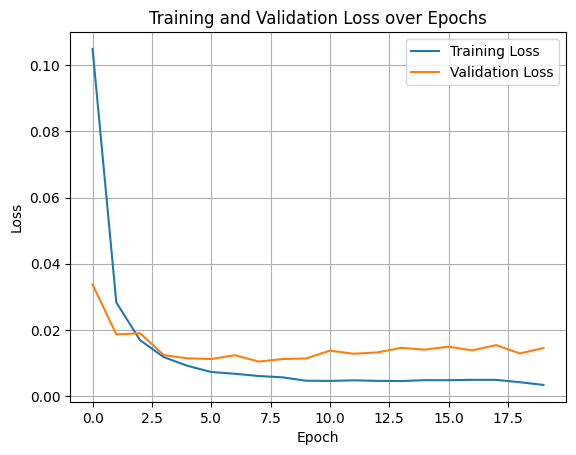

<All keys matched successfully>

In [121]:
def view_val_train_loss(avg_losses, avg_val_losses):
    plt.plot(avg_losses, label='Training Loss')
    plt.plot(avg_val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss over Epochs')
    plt.legend()
    plt.grid()
    plt.show()



def view_evaluation_sample(o_t, waypoints, model):
    model.eval()
    with torch.no_grad():
        input_tensor = o_t.unsqueeze(0).to(device).to(data_type)  # Add batch dimension
        predicted_waypoints = model(input_tensor).squeeze(0)  # Remove batch dimension

    # Denormalize and convert image for visualization
    o_t_cpu = o_t.to('cpu')
    for t, m, s in zip(o_t_cpu, mean, std):
        t.mul_(s).add_(m)
    o_t_cpu = o_t_cpu.permute(1, 2, 0).numpy()

    plt.imshow(o_t_cpu)
    plt.show()

    xy = waypoints[:, :2]
    xy_pred = predicted_waypoints[:, :2]
    x = xy[:, 0].cpu().numpy()
    y = xy[:, 1].cpu().numpy()
    x_pred = xy_pred[:, 0].cpu().numpy()
    y_pred = xy_pred[:, 1].cpu().numpy()

    # Axis scale
    max_value = max(max(abs(x)), max(abs(y))) + 0.5
    max_value_pred = max(max(abs(x_pred)), max(abs(y_pred))) + 0.5
    max_value = max(max_value, max_value_pred)

    plt.figure(figsize=(6, 6))
    plt.plot(x, y, marker='o')

    plt.plot(x_pred, y_pred, marker='x')
    plt.legend(['Ground Truth', 'Predicted'])

    # Label points 1–8
    for i in range(8):
        plt.text(x[i], y[i], str(i + 1), fontsize=12, ha='right', va='bottom')

    for i in range(8):
        plt.text(x_pred[i], y_pred[i], str(i + 1), fontsize=12, ha='left', va='top', color='red')

    # Formatting
    plt.xlim(-max_value, max_value)
    plt.ylim(-max_value, max_value)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.title('Waypoints in Robot-Centric Frame')
    plt.grid()
    plt.show()

view_val_train_loss(avg_losses, avg_val_losses)

model.load_state_dict(torch.load('best_model_epoch_8.pth'))

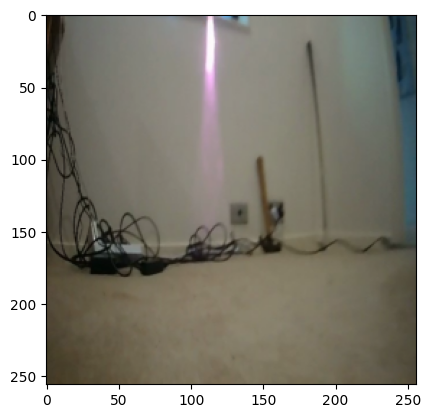

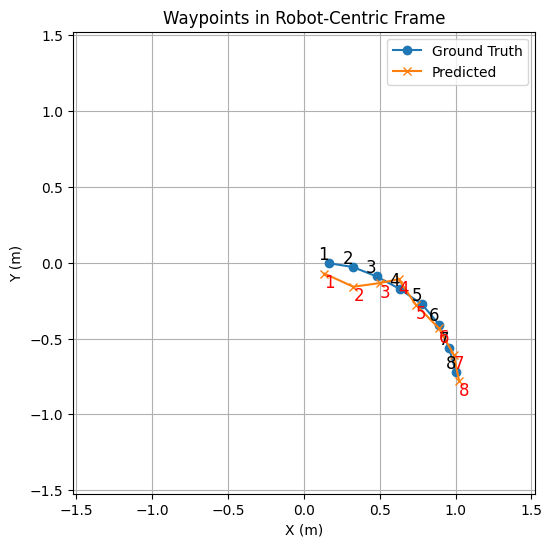

In [146]:
o_t, waypoints = full_dataset[np.random.randint(0, len(full_dataset))]
view_evaluation_sample(o_t, waypoints, model)

In [149]:
import time


dummy_input = torch.ones((1, C, H, W)).to(device).to(data_type)
start_time = time.time()
output = model(dummy_input)
end_time = time.time()
print(f"Inference time: {end_time - start_time:.6f} seconds")



Inference time: 0.002237 seconds


## Export the model to ONNX format


In [151]:
output_model = ModelV1()
output_model.load_state_dict(torch.load('best_model_epoch_8.pth'))
output_model.eval()

output_onnx_path = 'epv_model_v2.onnx'
dummy_input = torch.randn(1, C, H, W)
torch.onnx.export(output_model, 
                      dummy_input, 
                      output_onnx_path, 
                      opset_version=18,
                      export_params=True,
                      input_names=['input'],
                      output_names=['output'],
                      dynamo=False)



/var/folders/94/b4rb28zd70zg_3hd1pz8r6rh0000gn/T/ipykernel_48958/2925480434.py:7: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(output_model,


In [152]:
import onnx
onnx_model = onnx.load(output_onnx_path)
onnx.checker.check_model(onnx_model)
print("ONNX model is valid.")

ONNX model is valid.


In [153]:
total_params = sum(p.numel() for p in output_model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 135,096,208


In [89]:
dtype_size = {
    torch.float32: 4,
    torch.float16: 2,
    torch.bfloat16: 2,
    torch.int8: 1,
    torch.int32: 4,
}

total_bytes = 0
for p in output_model.parameters():
    total_bytes += p.numel() * dtype_size[p.dtype]

print(f"Model size: {total_bytes/1024/1024:.2f} MB")

Model size: 515.35 MB


In [101]:
array = np.fromfile('/Users/tom/Development/carbot_ai_model/tensor_output.bin', dtype=np.float32)
tensor = array.reshape(1, 3, 256, 256)
mean_np_array = np.array([0.485 * 0.255, 0.456 * 0.225, 0.406 * 0.225]).reshape(1, 3, 1, 1)
std_np_array = np.array([0.225, 0.225, 0.225]).reshape(1, 3, 1, 1)
x = (tensor[0] * std_np_array) + mean_np_array
x = x.squeeze(0)
x = x.clip(0, 1)
x.shape

(3, 256, 256)

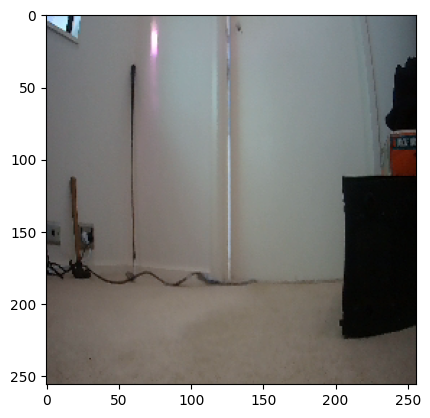

In [97]:
img = x.transpose(1, 2, 0)  # Convert from (C, H, W) to (H, W, C)
plt.imshow(img)
plt.show()

In [102]:
torch_tensor = torch.from_numpy(tensor).type(torch.float32)
output = output_model(torch_tensor)
print(output)

tensor([[[ 7.2500e-02,  6.6341e-03],
         [ 9.9097e-02,  3.2569e-02],
         [ 1.8222e-01, -1.8482e-04],
         [ 2.3690e-01,  6.2018e-03],
         [ 2.4473e-01,  4.2450e-02],
         [ 3.5221e-01, -6.2142e-03],
         [ 2.9503e-01,  4.1066e-02],
         [ 3.8970e-01,  1.6648e-03]]], grad_fn=<ViewBackward0>)
